# Homework 11


**Concepts covered:**

pandas `DataFrame`s: grouping data, querying `DataFrame`s, joining multiple `DataFrame`s, sampling.

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

It is **strictly forbidden to use any generative AI (e.g., ChatGPT, Claude, Gemini, CoPilot or any similar tools**) to write solutions for any assignment. Students who submit work that is not authentically their own individual work will earn a grade of 0 on this assignment.


**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [5]:
# shared imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.close("all")


**Note: This assignment is partially manually graded, so please allow some time for you to get your final scores.**

**Review Problem 1**

**Concept:** *`DataFrame`: initialization, line plots.*

**Task:**


Using the Starbucks stock dataset:

1. Load the `SBUX.csv` dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Create a line plot showing both the `high` and `low` prices over time.

Your plot should include:

* both high and low columns plotted together
* a title
* a key


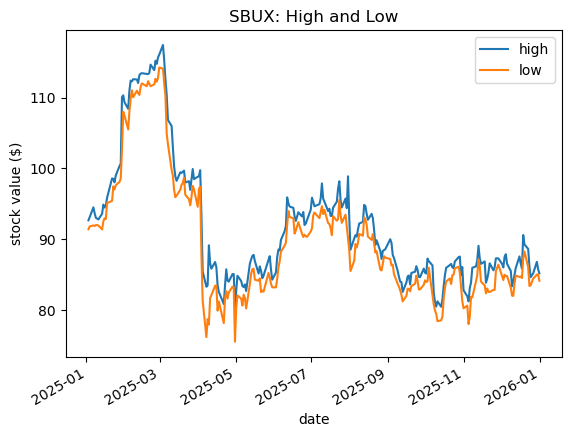

In [6]:
# reads the csv file
df_sbux = pd.read_csv("SBUX.csv")

# takes the date column and converts the date column to pandas datetime and sets the index
df_sbux.index = pd.to_datetime(df_sbux["date"], unit="s")

# plotting high and low as a line plot with the title. Adding y label and legend
df_sbux[["high", "low"]].plot(title="SBUX: High and Low")
plt.ylabel("stock value ($)")
plt.legend()
plt.show()

# test to check it's appearing as intended
# df_sbux

Review Problem 2

**Concept:** *`DataFrame`: initialization, descriptive statistics, histogram.*

**Task:**

Using the `SBUX.csv` dataset:

1. Load the dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Compute the **daily return** of the stock using the `close` column (percentage change).
4. Display the **descriptive statistics** of the daily returns.
5. Create a **histogram** of the daily returns using 25 bins.
6. Identify **outliers** where the return falls outside of **mean ± 3 standard deviations**.
7. Print:
    *  the upper and lower bounds
    * the number of values above and below these bounds
    * the list of outlier values (sorted by date)


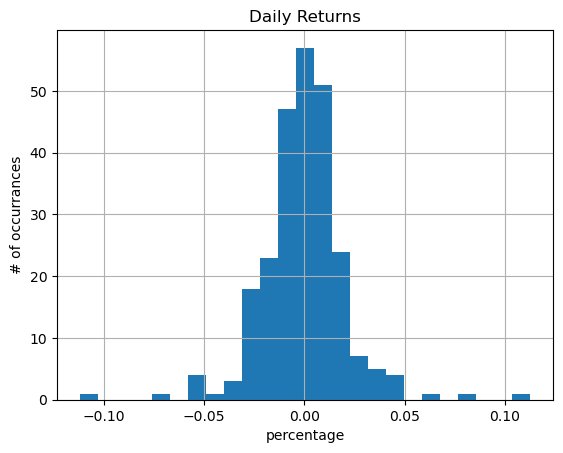

In [7]:
# reads the csv file
df_sbux = pd.read_csv("SBUX.csv")

# takes the date column and converts the date column to pandas datetime and sets the index
df_sbux.index = pd.to_datetime(df_sbux["date"], unit="s")

# computes the daily return, and using pct change syntax for percentage change
daily_return = df_sbux["close"].pct_change()

# lists and displays all of the descriptive statistics
descriptive_statistics = daily_return.describe()

# creates a histogram of the daily return variable above
daily_return.hist(bins=25)

# adds title, x and y labels
plt.title("Daily Returns")
plt.xlabel("percentage")
plt.ylabel("# of occurrances")

# getting mean and std to begin getting the upper and lower bounds
dailyreturn_mean = daily_return.mean()
dailyreturn_std = daily_return.std()

# getting the lower and upper bounds
lower_bound = dailyreturn_mean - 3 * (dailyreturn_std)
upper_bound = dailyreturn_mean + 3 * (dailyreturn_std)

# find outliers
outliers_low = daily_return < lower_bound
outliers_high = daily_return > upper_bound

# getting all of the outliers for low outliers or high outliers
outliers_list = daily_return[outliers_low | outliers_high]

# print(dailyreturn_mean)
# print(dailyreturn_std)
# daily_return # test




Test case for problem 2

In [8]:
# Test Case:
print(descriptive_statistics)
print()
print(f"The upper bounds are: {upper_bound}")
print(f"The lower bounds are: {lower_bound}")
print(f"Number of records above the upper bound: {outliers_high.sum()}")
print(f"Number of records below the upper bound: {outliers_low.sum()}")
print()
print("Outliers sorted by date:")
print(f"{outliers_list}")


count    249.000000
mean      -0.000130
std        0.021601
min       -0.112162
25%       -0.011336
50%        0.000107
75%        0.011323
max        0.112812
Name: close, dtype: float64

The upper bounds are: 0.06467188888830806
The lower bounds are: -0.06493212818695375
Number of records above the upper bound: 3
Number of records below the upper bound: 2

Outliers sorted by date:
date
2025-01-29 14:30:00    0.081366
2025-04-03 13:30:00   -0.112162
2025-04-04 13:30:00   -0.069794
2025-04-09 13:30:00    0.112812
2025-05-12 13:30:00    0.066874
Name: close, dtype: float64


**Problem 3**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Load the dataset into a DataFrame named `df_weather`.
2. Convert the `datetime` column to a pandas datetime format and set it as the index.
3. Use the icon column as a categorical variable and group the data by `icon`.
4. Create a **pie chart** showing the count of each weather icon category.

Your chart should include:
* labels for each category
* a title



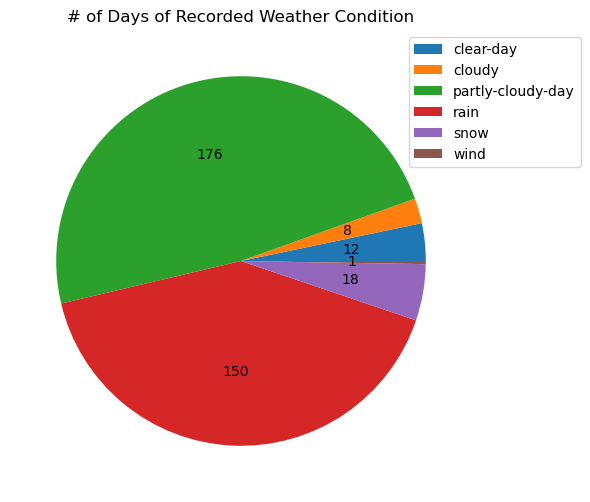

In [58]:
# loading the data set reading the csv
df_weather = pd.read_csv("02215_weather.csv")

# converting datetime column to pandas datetime format
df_weather.index = pd.to_datetime(df_weather["datetime"], format="%m/%d/%y")

# grouping weather data by icon
weather_icon_group_original = df_weather.groupby("icon")
weather_icon_groups = df_weather.groupby("icon").size()

# creating pie chart
fig, ax = plt.subplots(figsize=(8,6))

# labeling by the number of times the weather occurred
ax.pie(weather_icon_groups, 
       autopct=lambda p: int(p * sum(weather_icon_groups) / 100))

# title, added legend
plt.title("# of Days of Recorded Weather Condition")
plt.legend(labels=weather_icon_groups.index, 
           loc="upper right", 
           bbox_to_anchor=(1.25, 1)
)
plt.show()

# test checkin
# weather_icon_groups
# len(weather_icon_groups)
# weather_icon_groups.groups
# weather_icon_groups.mean(numeric_only=True)
# df_weather



**Problem 4**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a **histogram** of the `tempmax` column for each weather condition group.

Your plot should include:
* 25 bins
* transparency so overlapping distributions can be seen
* a legend
* a title


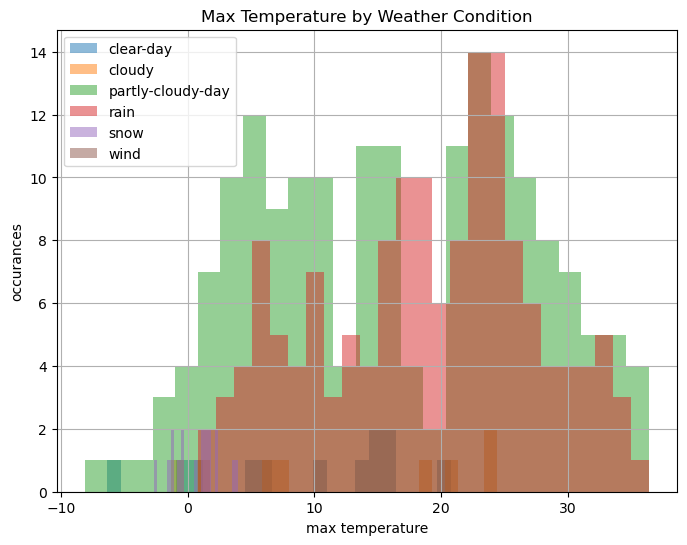

In [10]:
# using the existing grouped that is for icon, plotting histogram for tempmax
weather_icon_group_original["tempmax"].hist(
  bins=25,
  alpha=.5, # making histogram see through
  figsize=(8,6), # changing size of graph as a whole
  legend=True # adding legend
)

# title and labeling
plt.xlabel("max temperature")
plt.ylabel("occurances")
plt.title("Max Temperature by Weather Condition")
plt.show()


**Problem 5**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a histogram of the `precip` column for each weather condition group.

Your plot should include:

* 10 bins
* transparency so overlapping distributions can be seen
* a legend
* a title



Text(0.5, 1.0, 'Precipitation by Weather Condition')

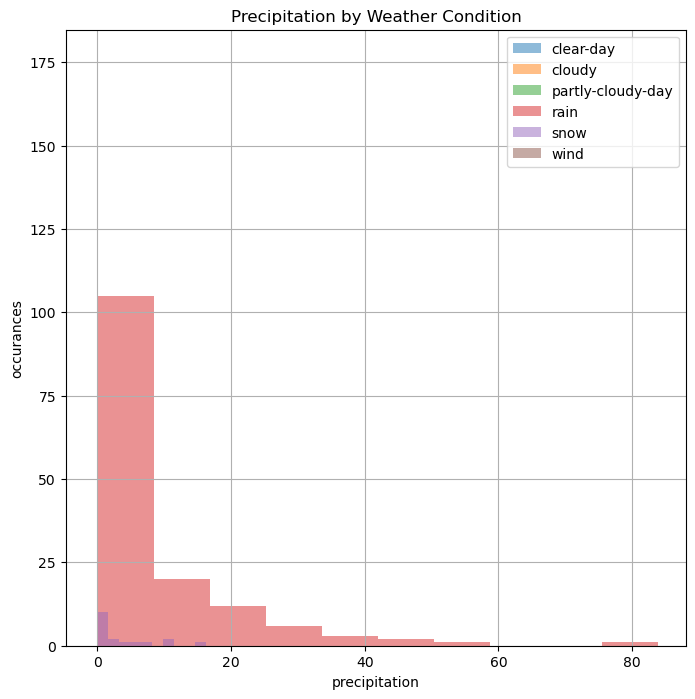

In [11]:
# using the existing grouped that is for icon, plotting histogram for precipitation
weather_icon_group_original["precip"].hist(
  bins=10,
  alpha=.5,
  figsize=(8,8),
  legend=True
)
plt.xlabel("precipitation")
plt.ylabel("occurances")
plt.title("Precipitation by Weather Condition")

**Problem 6**

**Concept:** *Grouping Data, plotting*


**Task:**


Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Compute the **mean** of the `tempmax` column for each weather condition group.
3. Create a **bar chart** to display the mean maximum temperature for each group.


Your plot should include:

* one bar for each weather icon category
* a title



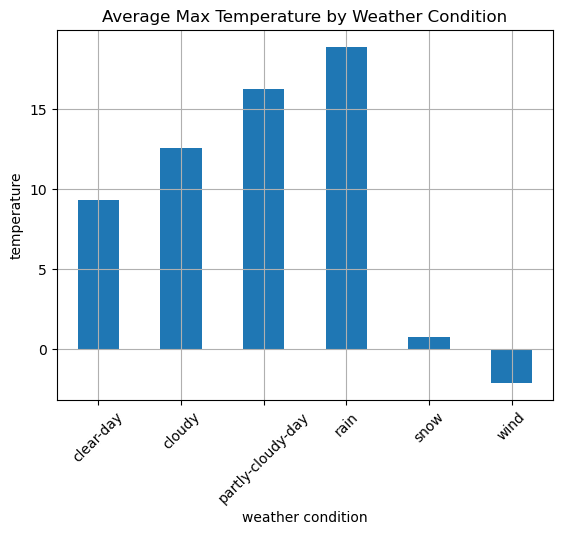

In [12]:
# created a variable to get the mean of tempmax for each icon and to plot it as a bar chart
tempmax_mean = weather_icon_group_original["tempmax"].mean().plot(kind="bar")

# title, labeling y axis, and rotating labels for easier reading, adding grid
plt.title("Average Max Temperature by Weather Condition")
plt.xlabel("weather condition")
plt.ylabel("temperature")
plt.xticks(rotation=45)
plt.grid()
plt.show()



**Problem 7**

**Concept:** *Grouping data, descriptive statistics*


**Task:**

Using the `02215_weather.csv` dataset:

1. Group the DataFrame by the `icon` column and store the result in a variable named `grouped_by_icon`.
2. Compute descriptive statistics for the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_statistics`.
3. Compute descriptive statistics for the `precip` column for each group and store the result in a variable named `grouped_precipitation_statistics`.
4. Compute the **mean** of the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_mean`.

Print all three results with clear labels:
* `"Tempmax grouped by conditions"`
* `"Precipitation grouped by conditions"`
* `"Mean of tempmax grouped by conditions"`


In [13]:
# loading the data set reading the csv
df_weather = pd.read_csv("02215_weather.csv")

#grouping by icon
grouped_by_icon = df_weather.groupby("icon")

# getting temp max for each group and getting the descriptive statistics per icon
grouped_tempmax_statistics = grouped_by_icon["tempmax"].describe()
print()
print('Tempmax grouped by conditions')
print(grouped_tempmax_statistics)

# getting precip for each group and getting the descriptive statistics per icon
grouped_precipitation_statistics = grouped_by_icon["precip"].describe()
print()
print('Precipitation grouped by conditions')
print(grouped_precipitation_statistics)

# getting temp max for each group and getting the mean per icon
grouped_tempmax_mean = grouped_by_icon["tempmax"].mean()
print()
print('Mean of tempmax grouped by conditions')
print(grouped_tempmax_mean)




Tempmax grouped by conditions
                   count       mean        std  min    25%    50%     75%  \
icon                                                                        
clear-day           12.0   9.316667   8.230965 -6.4   4.15  12.10  15.225   
cloudy               8.0  12.575000  10.423565 -1.3   4.95  13.05  21.350   
partly-cloudy-day  176.0  16.246023  10.533554 -8.1   7.20  15.65  25.000   
rain               150.0  18.904000   8.498037  0.8  12.60  19.90  24.600   
snow                18.0   0.750000   1.805628 -2.7  -0.65   1.25   1.775   
wind                 1.0  -2.100000        NaN -2.1  -2.10  -2.10  -2.100   

                    max  
icon                     
clear-day          20.8  
cloudy             24.4  
partly-cloudy-day  36.4  
rain               36.4  
snow                4.0  
wind               -2.1  

Precipitation grouped by conditions
                   count      mean        std    min      25%     50%  \
icon                              

QUERYING

The following data frame will be used in several questions.


In [40]:
# starter code
df_voter_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-11/newton_voters.csv", low_memory=False)
df_voter_data.index = df_voter_data["Voter ID Number"]
df_voter_data['Date of Birth'] = pd.to_datetime(df_voter_data['Date of Birth'])
df_voter_data

,Voter ID Number,Last Name,First Name,Residential Address - Street Number,Residential Address - Street Name,Residential Address - Apartment Number,Residential Address - Zip Code,Date of Birth,Date of Registration,Party Affiliation,Precinct Number,v20state,v21town,v21primary,v22general,v23town,voter_score
Voter ID Number,,,,,,,,,,,,,,,,,
10WLA0879000,10WLA0879000,W*,*I**,17,CIRCUIT AVE,3,2461,1980-01-03,2022-11-26,U,1,False,False,False,False,False,0
02JHE1841000,02JHE1841000,**F**,*A*******,193,OAK ST,606E,2464,1940-10-24,1995-05-15,D,1,True,False,True,True,False,3
05SSN2487000,05SSN2487000,**E****,****H**,1024,CHESTNUT ST,1,24641113,1986-11-28,2020-08-18,D,1,True,False,False,False,False,1
06GIA1393000,06GIA1393000,****F**,I****,1024,CHESTNUT ST,1,24641113,1993-03-23,2020-10-27,D,1,False,False,False,False,False,0
10KSA1343001,10KSA1343001,****E*,*****A,193,OAK ST,103E,2464,1943-12-15,2016-02-10,D,1,True,True,False,True,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10ZML2151000,10ZML2151000,***E****,*****E*,96,WABAN PK,NaN,2458,1951-08-31,2012-10-16,U,2A,True,False,False,True,True,3
01SMA2751001,01SMA2751001,*A*****,***I*,111,JEWETT ST,NaN,2458,1951-05-18,2020-06-06,D,2A,True,False,False,False,False,1
08YSA0278002,08YSA0278002,**B********,****A,22,WALNUT PK,NaN,24581434,1978-04-12,2017-09-24,R,2A,False,False,False,False,False,0


**Problem 8**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Determine the **total number of voters** and print the result.
2. Compute the count of voters in each **Party Affiliation** category.
3. Create a **pie chart** showing the distribution of voters by party affiliation.

Your plot should include:
* labels for each category
* a title that includes the total number of voters


Total voters: 58769
Total voters: Party Affiliation
U     32416
D     23108
R      2854
CC      110
L       103
J        28
T        27
O        22
A        20
Q        19
S        14
G        10
X         8
AA        7
Z         5
FF        4
GG        3
V         2
K         2
HH        1
P         1
E         1
H         1
Y         1
W         1
EE        1
Name: count, dtype: int64


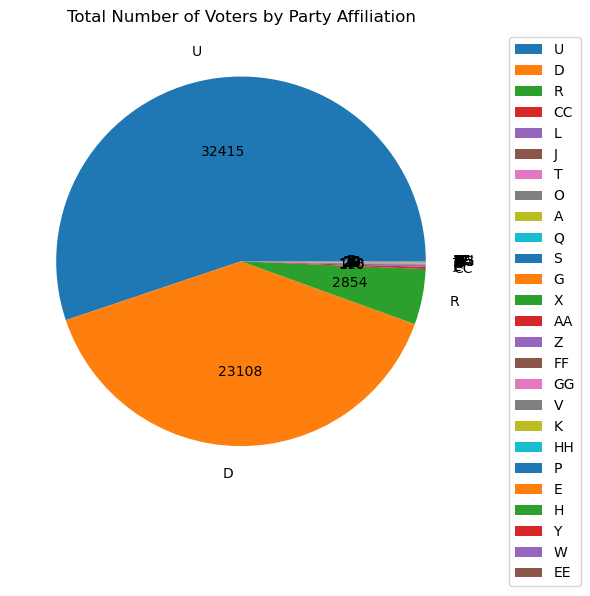

In [59]:
# getting number of voteres
total_voters = len(df_voter_data)
print(f"Total voters: {total_voters}")

# getting the number of voters in each party affiliation
party_affiliation = df_voter_data["Party Affiliation"].value_counts()
print(f"Total voters: {party_affiliation}")

# resizing the pie chart
plt.figure(figsize=(6,6))

# pie chart
# can't fix the overlapping
plt.pie(
  party_affiliation, 
  labels=party_affiliation.index,
  autopct=lambda p: int(p * sum(party_affiliation) / 100),
  labeldistance=1.15,
  textprops={"fontsize": 10}
  )
plt.legend(loc="upper right", 
           bbox_to_anchor=(1.25, 1))
# title
plt.title("Total Number of Voters by Party Affiliation")
plt.show()

**Problem 9**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_older_voters` that includes only voters born **before January 1, 1950**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these older voters.

Your plot should include:
* labels for each category
* a title that includes the number of older voters


Total voters born before January 1, 1950: 9073
Total voters born before January 1, 1950 by party affiliation: Party Affiliation
U     4381
D     4141
R      520
CC      14
L        5
T        4
O        2
Z        1
Q        1
A        1
AA       1
J        1
K        1
Name: count, dtype: int64


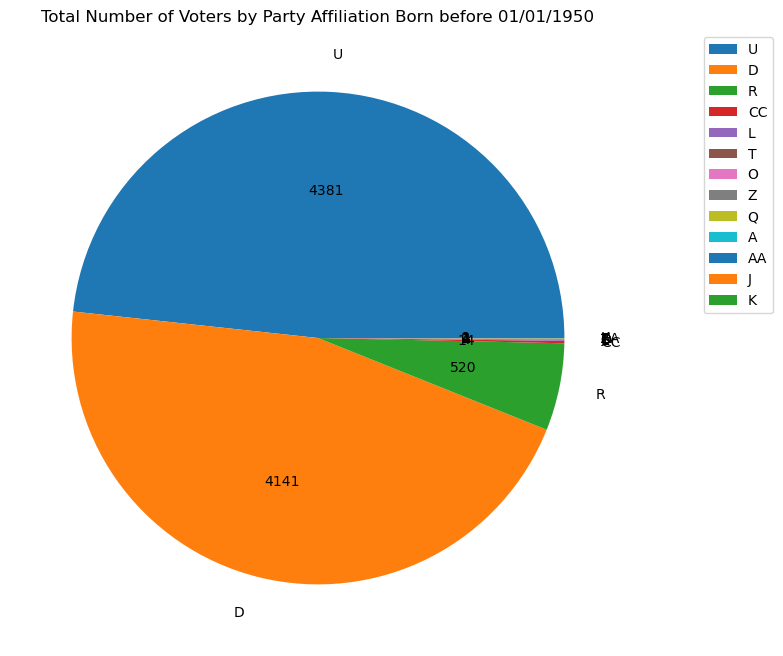

In [68]:
# using query, getting only voters born before 1950, then getting total voters
df_older_voters = df_voter_data.query("`Date of Birth` < '1950-01-01'")
total_voters = len(df_older_voters)
print(f"Total voters born before January 1, 1950: {total_voters}")

# getting the number of voters by party affiliation born before 1950
party_voters_1950 = df_older_voters["Party Affiliation"].value_counts()
print(f"Total voters born before January 1, 1950 by party affiliation: {party_voters_1950}")

# resizing the pie chart
plt.figure(figsize=(8,8))

# pie chart
# can't fix the overlapping
plt.pie(
  party_voters_1950, 
  labels=party_voters_1950.index,
   autopct=lambda p: int(p * sum(party_voters_1950) / 100),
  labeldistance=1.15,
  textprops={"fontsize": 10}
  )

# added legend
plt.legend(loc="upper right", 
           bbox_to_anchor=(1.25, 1))

# title
plt.title("Total Number of Voters by Party Affiliation Born before 01/01/1950")
plt.show()



**Problem 10**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_younger_voters` that includes only voters born **after January 1, 2000**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these Younger voters.

Your plot should include:
* labels for each category
* a title that includes the number of younger voters


Total voters born after January 1 2000: 5099
Total voters born after January 11/2000 by party affiliation: Party Affiliation
U     3533
D     1406
R      126
L       17
S        4
CC       3
J        2
A        2
HH       1
P        1
G        1
GG       1
AA       1
X        1
Name: count, dtype: int64


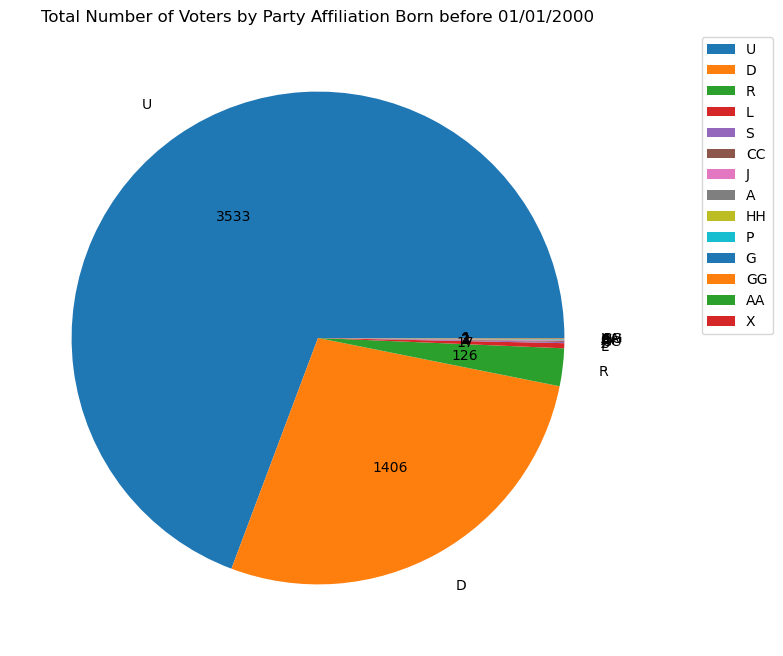

In [67]:
# using query, getting only voters born after 01/01/2000, then getting total voters
df_younger_voters = df_voter_data.query("`Date of Birth` > '2000-01-01'")
total_voters = len(df_younger_voters)
print(f"Total voters born after January 1 2000: {total_voters}")

# getting the number of voters by party affiliation born after 2000
party_voter_2000 = df_younger_voters["Party Affiliation"].value_counts()
print(f"Total voters born after January 11/2000 by party affiliation: {party_voter_2000}")

# resizing the pie chart
plt.figure(figsize=(8,8))

# pie chart
# can't fix the overlapping
plt.pie(
  party_voter_2000, 
  labels=party_voter_2000.index,
   autopct=lambda p: int(p * sum(party_voter_2000) / 100),
  labeldistance=1.15,
  textprops={"fontsize": 10}
  )

# added legend
plt.legend(loc="upper right", 
           bbox_to_anchor=(1.25, 1))

# title
plt.title("Total Number of Voters by Party Affiliation Born before 01/01/2000")
plt.show()





**Problem 11**

**Concept:** *Querying `DataFrame`s and graphing*



**Task:**

Using the `df_voter_data` DataFrame:
1. Identify all columns related to elections:
    * Select columns whose names contain the letter `"v"` but do **not** contain `"score"`
    * Store the result in a variable named `election_columns`

2. Compute the **voting participation percentage** for each election among all voters:
    * Store the result in a variable named `d1`
    * **Hint:** To calculate participation
        * Use `.sum()` on a column to count how many voters participated
        * Divide by the total number of voters using `len(df)`
        * Multiply by 100 to convert to a percentage

3. Create a filtered DataFrame named `df_high_voter_score`:
    * Include only voters with `voter_score >= 4`
    * Print the number of voters in this group

4. Compute the **voting participation percentage** for this group:
    * Store the result in a variable named `d2`

5. Create a filtered DataFrame named `df_unenrolled`:
    * Include only voters with `"Party Affiliation" == "U "`
    * Print the number of voters in this group

6. Compute the voting participation percentage for this group:
    * Store the result in a variable named `d3`

7. Combine the results into a new DataFrame named `d`:
    * Index should be the election columns
    * Columns should be:
        * `"all voters"`
        * `"high-propensity voters"`
        * `"unenrolled voters"`

8. Create a **bar chart** from this combined DataFrame.

Your plot should include:
* a title
* a key

In [ ]:
# Your Solution




**Problem 12**

**Concept:** *Joining `DataFrame`s*


**Task:**

You are given two DataFrames:
* `submissions`, which contains student IDs and their homework submission IDs
* `grades`, which contains homework grades indexed by submission ID

Using these DataFrames:
1. Inspect both DataFrames by printing them.
2. Join the `submissions` DataFrame with the `grades` DataFrame:
    * Match the `hw1_submission` column in `submissions` with the index of `grades`
    * Store the result in a variable named `result`
3. Update the index of the resulting DataFrame:
    * Set the index to the `student_id` column
4. Create a new DataFrame named `result_df`:
    * Remove the `student_id` column
5. Print the final DataFrame


Starter code:

In [ ]:
# STARTER CODE:
submissions = pd.DataFrame(data={"student_id": ["U100", "U101", "U102", "U103", "U104"],
                        "hw1_submission": ["c1325", "b231", "a512", "e9999", "d8234"]})

grades = pd.DataFrame(index=["a512", "b231", "c1325", "d8234", "e9999"],
                        data={"hw1_grade": [0.99, 0.50, 0.62, 0.78, 1.00]} )


In [ ]:
# Your Solution




**Problem 13**

**Concept:** *Joining `DataFrame`s*



**Task:**

You are given two datasets:
* `design_materials.tsv`, which contains materials and the quantity required per bed
* `material_costs.tsv`, which contains the cost per unit for each material

Using these datasets:
1. Load both datasets from the provided `.tsv` files using the correct separator.
2. Merge the two DataFrames:
    * Join on the `material` column
    * Store the result in a variable named `df_costs`
3. Create a new column named `cost`:
    * Compute it as:

      **quantity_per_bed × unit_cost**
4. Print the resulting DataFrame

In [ ]:
# Your Solution




**Problem 14**

**Concept:** *joining `DataFrame`s*


**Task:**

You are given three stock datasets:
* BAC
* GM
* SBUX

Using these datasets:
1. Load each dataset into separate DataFrames:
    * `df_bac`, `df_gm`, and `df_sbux`
2. Convert the `date` column in each DataFrame to pandas datetime format and set it as the index.
3. Create a new DataFrame named `df_stock_prices`:
    * Use the index from `df_bac`
    * Add the following columns:
        * `"bac"` from `df_bac["close"]`
        * `"gm"` from `df_gm["close"]`
        * `"sbux"` from `df_sbux["close"]`
4. Create a **line plot** showing the stock prices over time.

Your plot should include:
* all three stocks on the same chart
* a title

In [ ]:
# Your Solution




**Problem 15**

**Concept:** *joining `DataFrame`s*


**Task:**

Using the `df_stock_prices` DataFrame from **Problem 14**:
1. Compute the **relative prices** of each stock:
    * Divide all values by the first row of the DataFrame
    * Store the result in a variable named `df_stock_prices_relative`
2. Create a **line plot** of the relative prices.

Your plot should include:
* all three stocks on the same chart
* a title

In [ ]:
# Your Solution


